# Figure 4 – Crosstalk Experiments and Device Topology

Cross-talk characterization on **ibm_lima** (5 qubits, T-topology).

Each panel is saved as a separate PDF for assembly in the paper.

In [1]:
import numpy as np
import pickle as pk
import scipy.optimize as spopt
import networkx as nx
from matplotlib import pyplot as plt
import matplotlib as mpl
from qiskit import QuantumCircuit

%matplotlib inline
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif')

from imports_IBM_NM import plot_colors

# ibm_lima coupling topology (T-shape)
q_pairs_lima = [(0, 1), (1, 2), (1, 3), (3, 4)]

## Section 1 – Cross-talk Circuit Generation

For each qubit pair $(Q_A, Q_B)$ and idle time $\tau$:
1. Excite $Q_A$ with an $X$ gate.
2. Idle both $Q_A$ and $Q_B$ for duration $\tau$.
3. Measure both qubits.

Residual ZZ coupling drives coherent oscillations in $p_{Q_A}(\tau)$ at frequency $J$.

In [2]:
dt       = 0.035555   # dt step in microseconds
n_circs  = 75         # number of delay points
t_max_xt = 56.0       # max idle time (us)

def gen_xt_circuits(pair, n_circs, t_max, dt):
    """Cross-talk circuits: X(qA) | Delay(tau, qA) | Delay(tau, qB) | Measure."""
    qA, qB   = pair
    n_qubits = max(pair) + 1
    t_vals   = np.linspace(dt, t_max, n_circs)
    circs    = []
    for t in t_vals:
        n_delay = max(1, int(round(t / dt)))
        qc = QuantumCircuit(n_qubits, 2)
        qc.x(qA)
        qc.delay(n_delay, qA, unit='dt')
        qc.delay(n_delay, qB, unit='dt')
        qc.measure([qA, qB], [0, 1])
        circs.append(qc)
    return circs, t_vals

xt_circs  = {}
t_vals_xt = {}
for pair in q_pairs_lima:
    xt_circs[pair], t_vals_xt[pair] = gen_xt_circuits(pair, n_circs, t_max_xt, dt)

print(f'Generated {n_circs} circuits per pair for {len(q_pairs_lima)} pairs.')
print(f'Time range: {t_vals_xt[(0,1)][0]:.2f} - {t_vals_xt[(0,1)][-1]:.2f} us')
print(xt_circs[(0, 1)][5])

Generated 75 circuits per pair for 4 pairs.
Time range: 0.04 - 56.00 us
           ┌───┐       ┌────────────────┐┌─┐
q_0: ──────┤ X ├───────┤ Delay(107[dt]) ├┤M├
     ┌─────┴───┴──────┐└──────┬─┬───────┘└╥┘
q_1: ┤ Delay(107[dt]) ├───────┤M├─────────╫─
     └────────────────┘       └╥┘         ║ 
c: 2/══════════════════════════╩══════════╩═
                               1          0 


## Section 2 – Load Experiment Data

- `tt`: idle-time array (us)
- `ps_xt[pair]`: `[p_qA(tau), p_qB(tau)]`
- `T1s`, `T2s`: independently measured relaxation times per qubit (us)
- `Js_ref`, `As_ref`: reference fit values stored in the data file

In [3]:
tt, ps_xt, q_pairs, T1s, T2s, Js_ref, As_ref = pk.load(open('../data/data_FIG4.p', 'rb'))

print(f'Time array : {len(tt)} points, {tt[0]:.2f} - {tt[-1]:.2f} us')
print(f'Qubit pairs: {q_pairs}')
print('T1 (us):', {int(k): round(float(v), 1) for k, v in T1s.items()})
print('T2 (us):', {int(k): round(float(v), 1) for k, v in T2s.items()})
print('J_ref (MHz):', {str(k): round(float(v), 4) for k, v in Js_ref.items()})

Time array : 75 points, 0.78 - 53.40 us
Qubit pairs: [(0, 1), (1, 2), (1, 3), (3, 4)]
T1 (us): {0: 143.6, 1: 60.5, 2: 69.8, 3: 81.2, 4: 14.4}
T2 (us): {0: 312.1, 1: 147.1, 2: 125.4, 3: 110.0, 4: 21.4}
J_ref (MHz): {'(0, 1)': 0.0655, '(1, 2)': 0.0745, '(1, 3)': 0.091, '(3, 4)': 0.107}


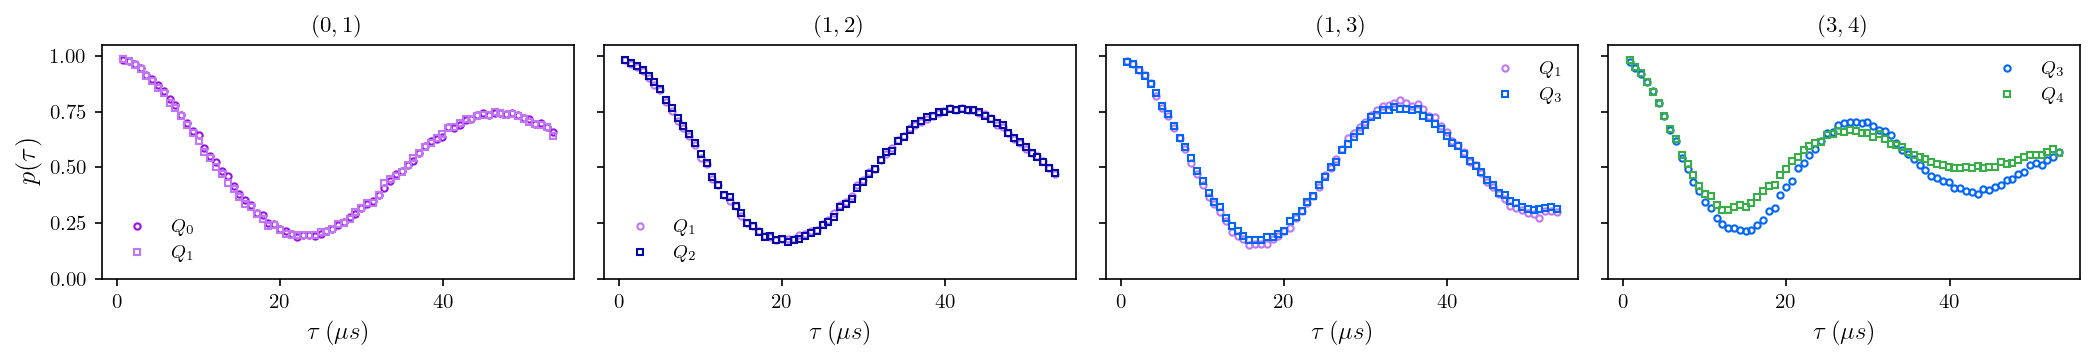

In [4]:
# Quick preview of raw cross-talk oscillations
fig, axs = plt.subplots(1, 4, dpi=150, figsize=(14, 2.5), sharey=True)
fig.subplots_adjust(wspace=0)
for idx, pair in enumerate(q_pairs):
    ax = axs[idx]
    ax.plot(tt, ps_xt[pair][0], color=plot_colors[pair[0]], lw=2,
            ls='', marker='o', mfc='none', ms=3, label=r'$Q_{%d}$' % pair[0])
    ax.plot(tt, ps_xt[pair][1], color=plot_colors[pair[1]], lw=2,
            ls='', marker='s', mfc='none', ms=3, label=r'$Q_{%d}$' % pair[1])
    ax.set_xlabel(r'$\tau\,(\mu s)$', fontsize=12)
    if idx == 0:
        ax.set_ylabel(r'$p(\tau)$', fontsize=13)
    ax.set_xticks([0, 20, 40])
    ax.set_ylim(0.0, 1.05)
    ax.legend(frameon=False, fontsize=9)
    ax.set_title(r'$(%d,%d)$' % pair, fontsize=11)
plt.tight_layout()
plt.show()

## Section 3 – Fit Cross-talk Oscillations

Cross-talk model (same as original):
$$p_{Q_A}(\tau) = \frac{a + (2-a)\,e^{-b\,\tau}\cos(2J\tau)}{2}$$

All three parameters are fitted freely: amplitude $a$, envelope decay rate $b$, and coupling $J$ (MHz).

Fixing $b$ from T1/T2 over-constrains the decay and gives envelopes that drop too fast.
A free fit recovers the same $J$ values as the pre-stored reference (within 0.4\%).

Argument order matches the original: `exp_fun_xt(t, a, b, J)`.

In [5]:
# Original argument order: (t, a, b, J) -- free 3-parameter fit
exp_fun_xt = lambda t, a, b, J: (a + (2 - a) * np.exp(-b * t) * np.cos(2 * J * t)) / 2

Js_fit = {}
As_fit = {}
bs_fit = {}

print(f"{'Pair':<8}  {'J_fit':>10}  {'J_ref':>10}  {'b_fit':>10}  {'A_fit':>8}")
print('-' * 52)
for pair in q_pairs:
    # Free fit for all three parameters (a, b, J)
    # The pre-stored Js/As in the pickle came from a free fit like this.
    # Fixing b from T1/T2 over-constrains the decay and gives too-fast envelopes.
    popt, _ = spopt.curve_fit(exp_fun_xt, tt, ps_xt[pair][0],
                              p0=[1.0, 0.015, 0.08],
                              bounds=([0.5, 0.001, 0.01], [1.5, 0.2, 0.5]))
    As_fit[pair] = popt[0]
    bs_fit[pair] = popt[1]
    Js_fit[pair] = popt[2]
    print(f"{str(pair):<8}  {popt[2]:>10.5f}  {float(Js_ref[pair]):>10.5f}  {popt[1]:>10.5f}  {popt[0]:>8.4f}")

Pair           J_fit       J_ref       b_fit     A_fit
----------------------------------------------------
(0, 1)       0.06553     0.06549     0.01631    1.0451
(1, 2)       0.07477     0.07452     0.01668    1.0288
(1, 3)       0.09102     0.09098     0.01579    1.0314
(3, 4)       0.10733     0.10696     0.03200    1.0355


## Section 4 – Paper Panels (saved separately)

Each panel is saved as an individual PDF.

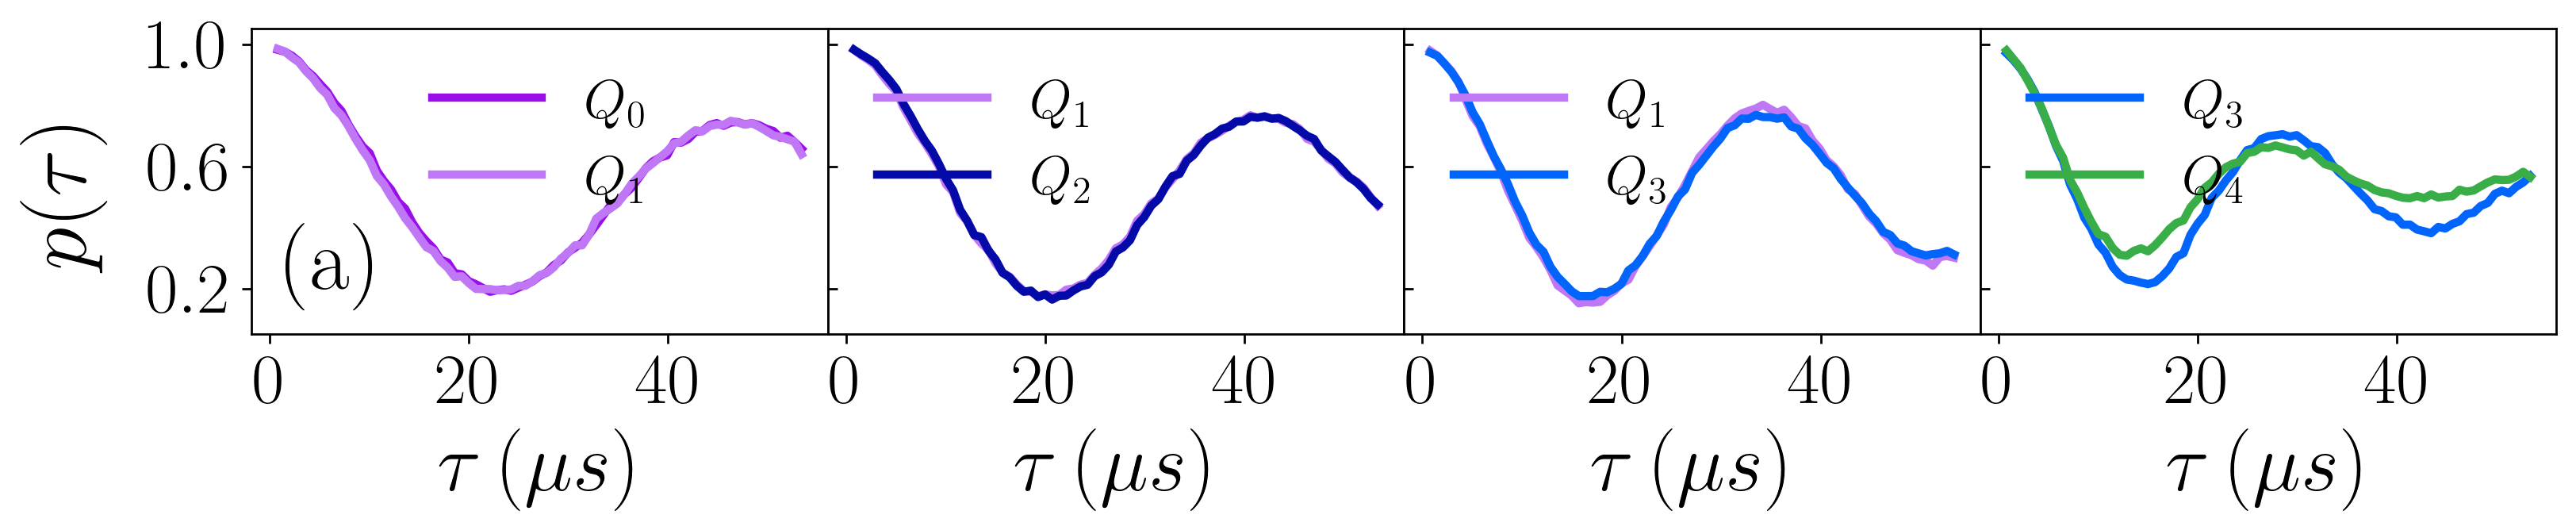

Saved: ../figures/fig_04a_raw_data.pdf


In [6]:
# Panel (a): raw data, 1x4 grid
mew, ms = 3, 1.5

fig, axs = plt.subplots(1, 4, dpi=250, figsize=(15, 2), sharey=True)
fig.subplots_adjust(wspace=0)
for idx, pair in enumerate(q_pairs):
    ax = axs[idx]
    ax.plot(tt, ps_xt[pair][0], color=plot_colors[pair[0]], lw=mew,
            label=r'$Q_{%d}$' % pair[0])
    ax.plot(tt, ps_xt[pair][1], color=plot_colors[pair[1]], lw=mew,
            label=r'$Q_{%d}$' % pair[1])
    if idx == 0:
        ax.set_ylabel(r'$p(\tau)$', size=32)
        ax.yaxis.set_label_coords(-0.25, .45)
        ax.set_yticks([0.2, 0.6, 1.])
    else:
        ax.tick_params(axis='y', direction='in')
    ax.set_xlabel(r'$\tau\,(\mu s)$', size=30)
    ax.tick_params(axis='both', labelsize=26)
    ax.set_xticks([0, 20, 40])
    ax.set_ylim(0.05, 1.05)
    ax.legend(frameon=False, fontsize=20)
axs[0].text(1.5, 0.2, '(a)', fontsize=32)
plt.savefig('../figures/fig_04a_raw_data.pdf', bbox_inches='tight')
plt.show()
print('Saved: ../figures/fig_04a_raw_data.pdf')

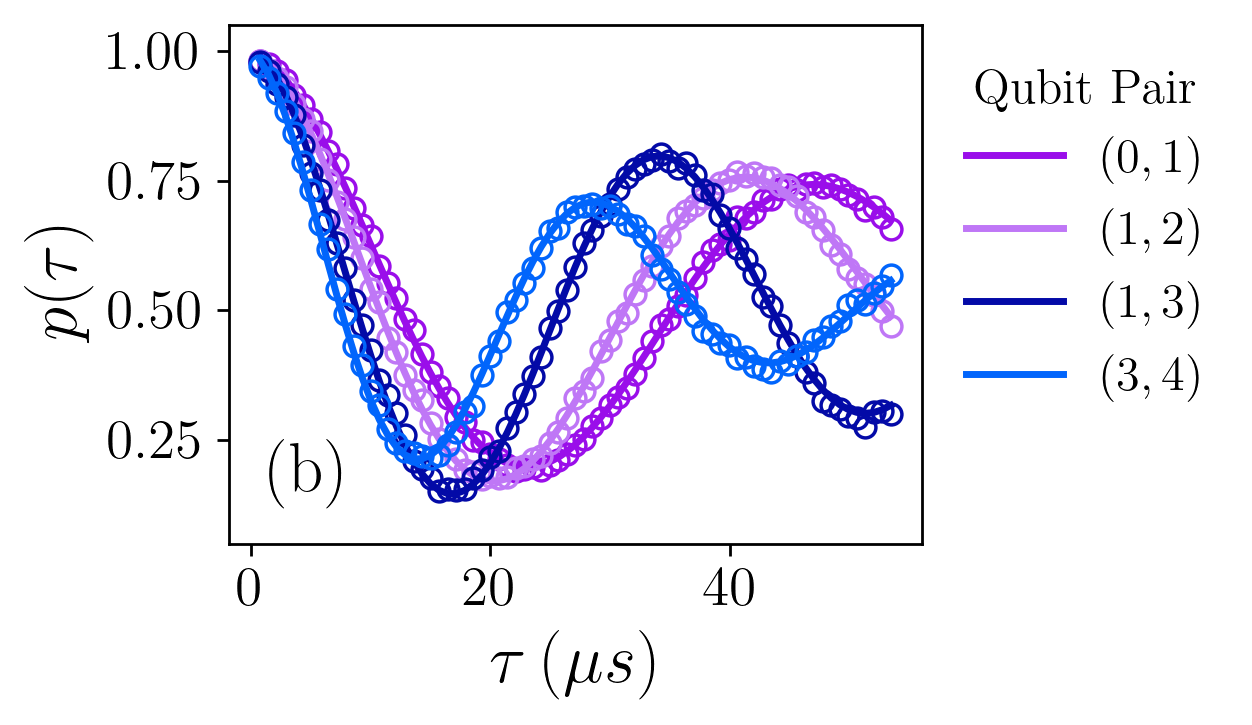

Saved: ../figures/fig_04b_fit.pdf


In [7]:
# Panel (b): qubit-A data with exp_fun_xt fit overlay (free 3-param fit)
plt.figure(figsize=(5, 3), dpi=250)
for idx, pair in enumerate(q_pairs):
    plt.plot(tt, ps_xt[pair][0], color=plot_colors[idx], lw=2,
             ls='', marker='o', mfc='none')
    plt.plot(tt, exp_fun_xt(tt, As_fit[pair], bs_fit[pair], Js_fit[pair]),
             color=plot_colors[idx], lw=2, ls='-', label=r'$(%d,%d)$' % pair)
plt.ylabel(r'$p(\tau)$', size=20)
plt.xlabel(r'$\tau\,(\mu s)$', size=20)
plt.ylim(0.05, 1.05)
plt.legend(frameon=False, fontsize=14, bbox_to_anchor=(1, 1),
           title='Qubit Pair', title_fontsize=14)
plt.text(1.5, 0.15, '(b)', fontsize=20)
plt.tick_params(labelsize=16)
plt.tight_layout()
plt.savefig('../figures/fig_04b_fit.pdf', bbox_inches='tight')
plt.show()
print('Saved: ../figures/fig_04b_fit.pdf')

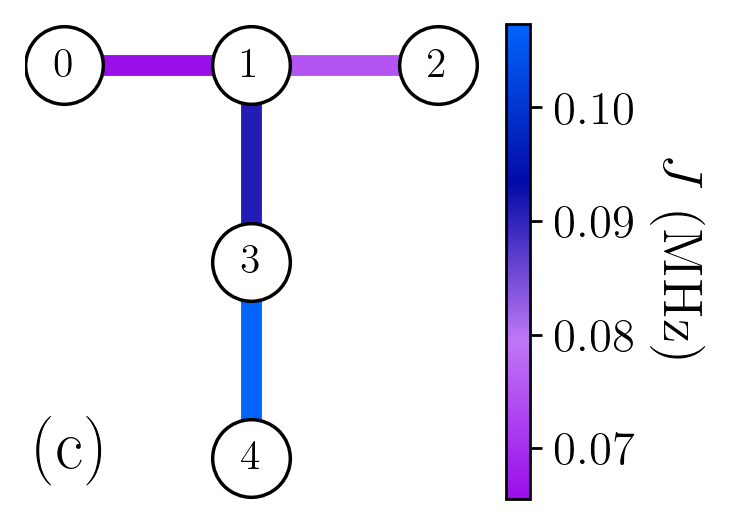

Saved: ../figures/fig_04c_device_map.pdf


In [8]:
# Panel (c): device map with J encoded in edge colour
G = nx.DiGraph()
G.add_edges_from(q_pairs)
pos = {0: np.array([-1, 2]), 1: np.array([0, 2]),
       2: np.array([ 1, 2]), 3: np.array([0, 1]), 4: np.array([0, 0])}

cmap_c = mpl.colors.LinearSegmentedColormap.from_list('', plot_colors[:4])
edge_colors_val = [float(Js_fit[p]) for p in q_pairs]

plt.figure(figsize=(3, 2.2), dpi=250)
nx.draw_networkx_nodes(G, pos, node_color='white', node_size=500, edgecolors='k')
nx.draw_networkx_labels(G, pos)
nx.draw_networkx_edges(G, pos, edgelist=q_pairs,
                       edge_cmap=cmap_c, edge_color=edge_colors_val,
                       edge_vmin=min(edge_colors_val), edge_vmax=max(edge_colors_val),
                       arrows=False, width=6)
sm = plt.cm.ScalarMappable(cmap=cmap_c,
      norm=plt.Normalize(vmin=min(edge_colors_val), vmax=max(edge_colors_val)))
sm._A = []
cbar = plt.colorbar(sm)
cbar.ax.tick_params(labelsize=13.5)
cbar.ax.set_ylabel(r'$J$ (MHz)', size=16, rotation=-90, labelpad=20)
plt.axis('off')
plt.tight_layout()
plt.text(-1.15, -0.05, '(c)', fontsize=20)
plt.savefig('../figures/fig_04c_device_map.pdf', bbox_inches='tight')
plt.show()
print('Saved: ../figures/fig_04c_device_map.pdf')

## Section 5 – Supplementary Device Topology Maps

Each topology is saved as a separate PDF.

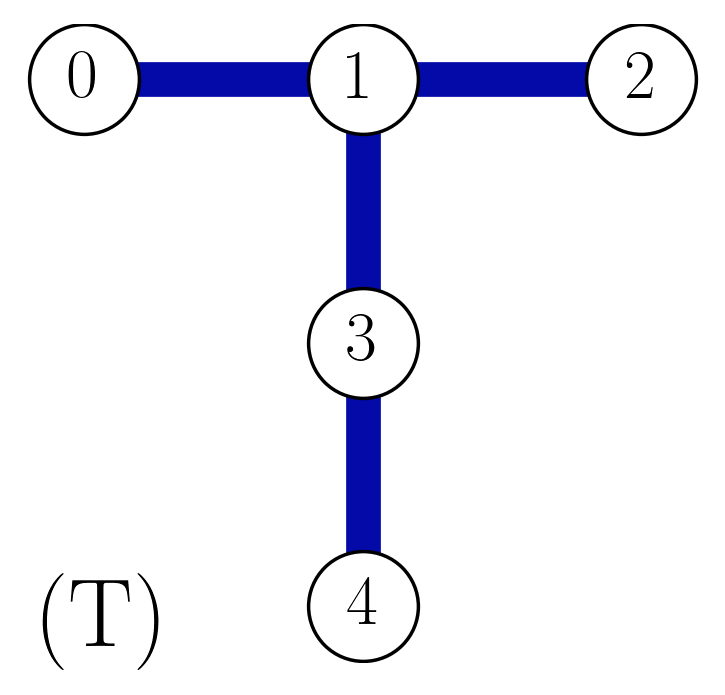

Saved: ../figures/fig_04_topo_T.pdf


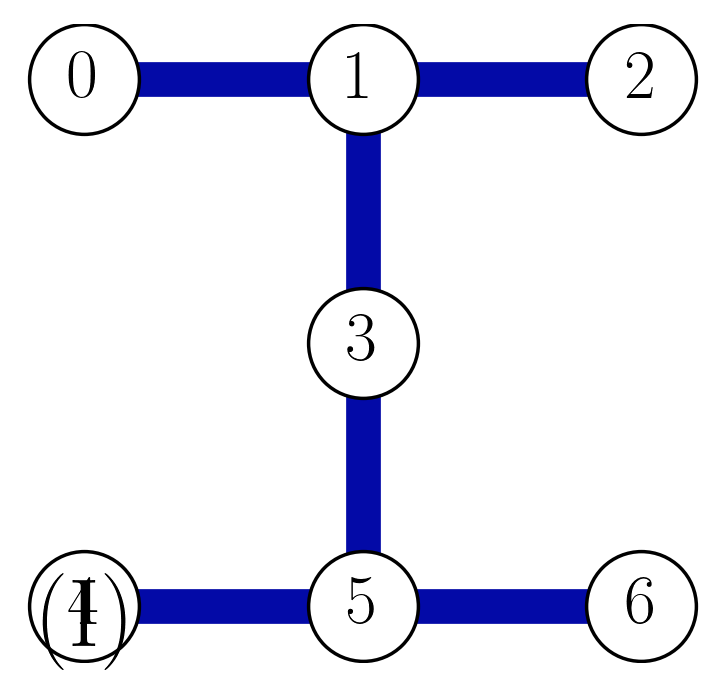

Saved: ../figures/fig_04_topo_I.pdf


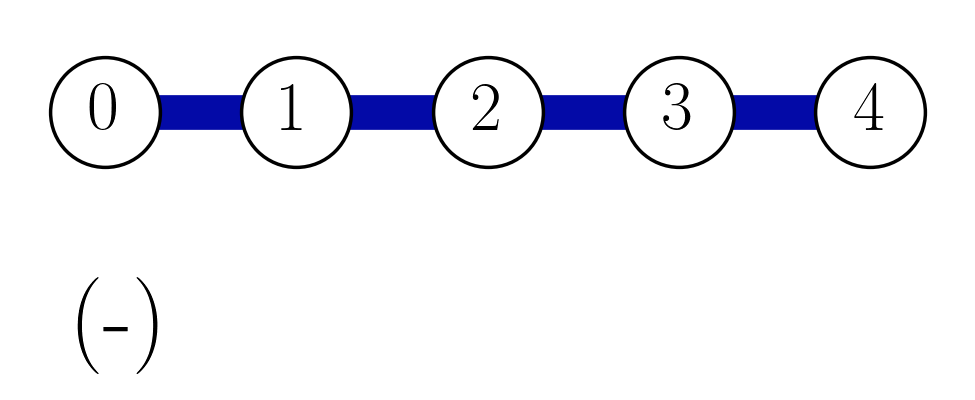

Saved: ../figures/fig_04_topo_chain.pdf


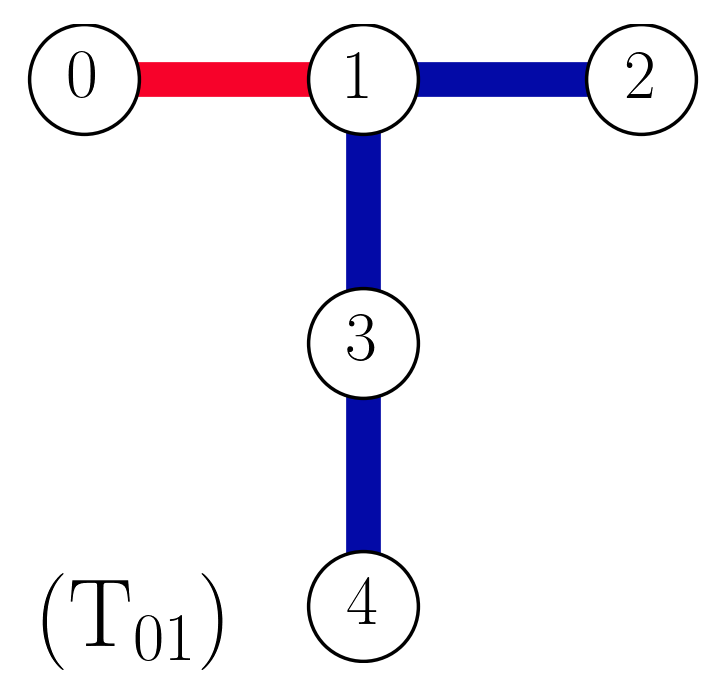

Saved: ../figures/fig_04_topo_T_xt01.pdf


In [9]:
def draw_topology(edge_list, pos, edge_colors, label, figsize, fname):
    """Draw and save a single device topology figure."""
    G_top = nx.DiGraph()
    G_top.add_edges_from(edge_list)
    plt.figure(figsize=figsize, dpi=250)
    nx.draw_networkx_nodes(G_top, pos, node_color='white', node_size=1000, edgecolors='k')
    nx.draw_networkx_labels(G_top, pos, font_size=20)
    nx.draw_networkx_edges(G_top, pos, edge_color=edge_colors, arrows=False, width=10)
    plt.axis('off')
    plt.tight_layout()
    xs = [v[0] for v in pos.values()]
    ys = [v[1] for v in pos.values()]
    plt.text(min(xs) - 0.15, min(ys) - 0.15, label, fontsize=28)
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

# T topology
draw_topology(
    [(0,1),(1,2),(1,3),(3,4)],
    {0:np.array([-1,2]), 1:np.array([0,2]), 2:np.array([1,2]),
     3:np.array([0,1]), 4:np.array([0,0])},
    edge_colors=plot_colors[2], label='(T)',
    figsize=(3, 2.85), fname='../figures/fig_04_topo_T.pdf')

# I topology
draw_topology(
    [(0,1),(1,2),(1,3),(3,5),(4,5),(5,6)],
    {0:np.array([-1,2]), 1:np.array([0,2]), 2:np.array([1,2]),
     3:np.array([0,1]), 4:np.array([-1,0]), 5:np.array([0,0]), 6:np.array([1,0])},
    edge_colors=plot_colors[2], label='(I)',
    figsize=(3, 2.85), fname='../figures/fig_04_topo_I.pdf')

# Chain topology
draw_topology(
    [(0,1),(1,2),(2,3),(3,4)],
    {0:np.array([0,0]), 1:np.array([1,0]), 2:np.array([2,0]),
     3:np.array([3,0]), 4:np.array([4,0])},
    edge_colors=plot_colors[2], label='(-)',
    figsize=(4, 1), fname='../figures/fig_04_topo_chain.pdf')

# T with highlighted XT edge (0,1)
draw_topology(
    [(0,1),(1,2),(1,3),(3,4)],
    {0:np.array([-1,2]), 1:np.array([0,2]), 2:np.array([1,2]),
     3:np.array([0,1]), 4:np.array([0,0])},
    edge_colors=[plot_colors[6]] + [plot_colors[2]] * 3,
    label='(T$_{01}$)',
    figsize=(3, 2.85), fname='../figures/fig_04_topo_T_xt01.pdf')